# Lecture A09: Modeling Events

Companion notebook for [[Lecture A09 - Modeling Events]]. Prerequisites: [[A01|A01]] through [[A08|A08]].

**Part 1** — Lecture walkthrough: fundamental count distributions, logit/logistic functions, binomial regression, Simpson's paradox via UC Berkeley admissions simulation, total vs direct effect models, post-stratification

**Part 2** — Applied exercises: real estate transaction counts (Binomial), forensic binary classification (Bernoulli/logistic), municipality admission-style structural effects, post-stratification for national price index

**Convention:** 89% credible intervals. Log-odds scale for parameters, probability scale for interpretation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from scipy.special import expit, logit
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 150,
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

C_PRIOR = "#9ca3af"
C_POSTERIOR = "#2563eb"
C_LIKELIHOOD = "#dc2626"
C_DATA = "#059669"
C_ACCENT = "#d97706"
C_POINT = "#111827"
C_PURPLE = "#7c3aed"

DATA_DIR = Path("../data")
CI_LEVEL = 0.89
N_SAMPLES = 10_000

---

# Part 1: Lecture Walkthrough

## 1. Fundamental Count Distributions

Visualizing the distributions used for event modeling. Each is the maximum entropy distribution for its constraints.

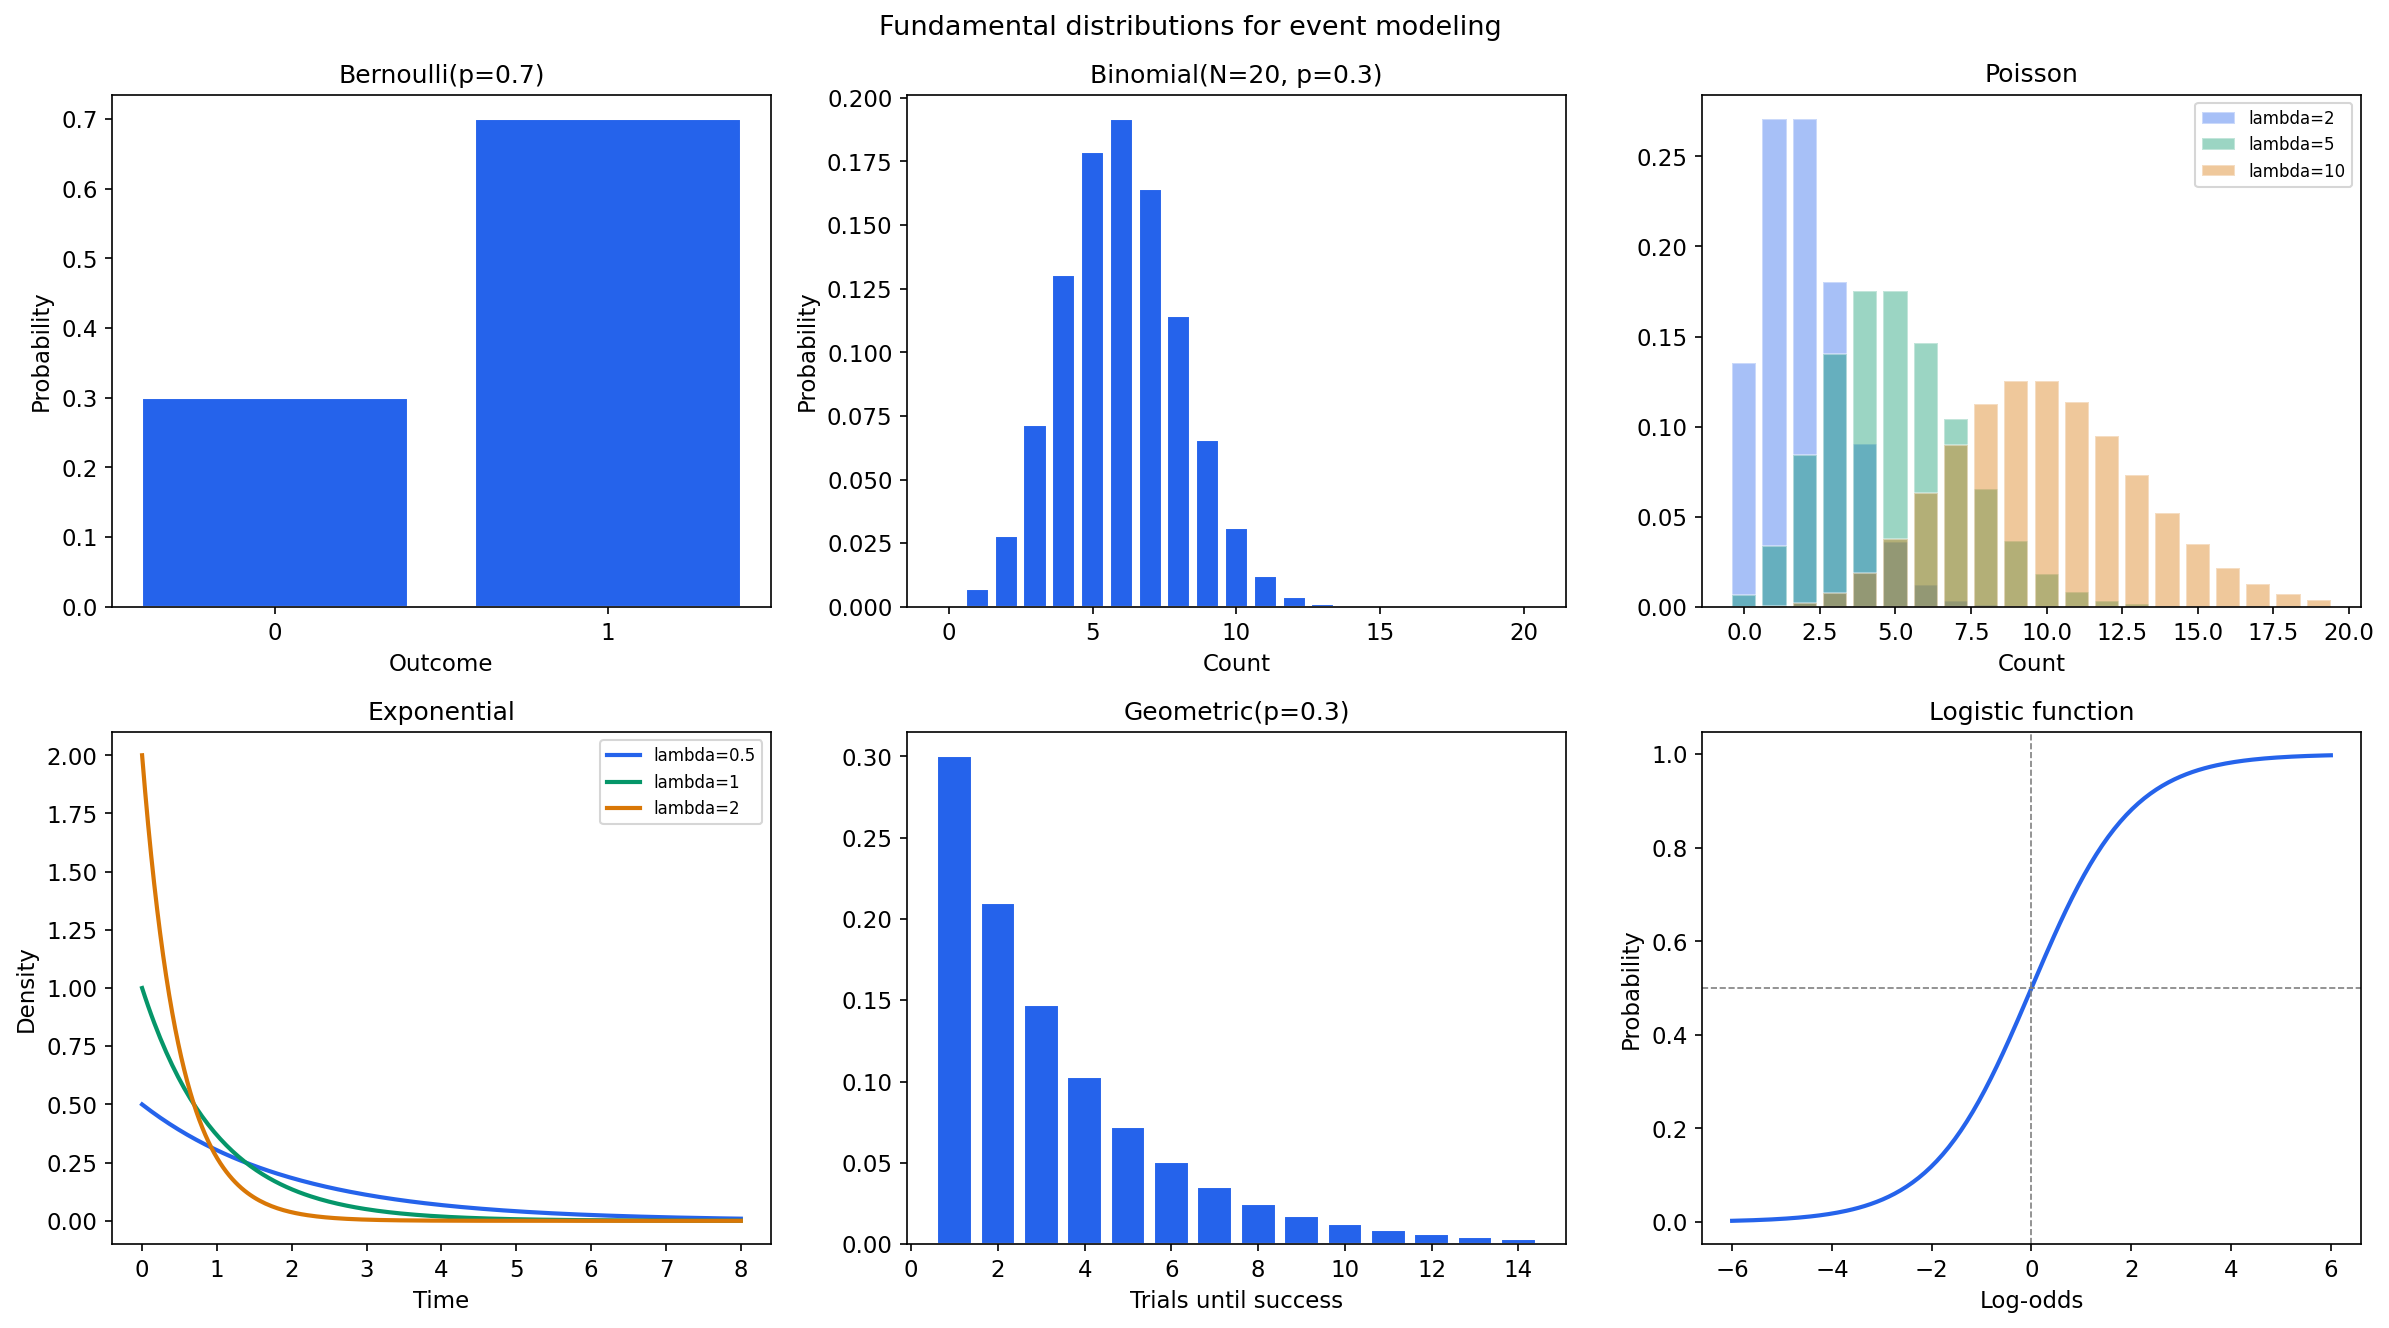

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Bernoulli
axes[0,0].bar([0, 1], [0.3, 0.7], color=C_POSTERIOR, edgecolor="white")
axes[0,0].set_title("Bernoulli(p=0.7)"); axes[0,0].set_xticks([0,1])
axes[0,0].set_xlabel("Outcome"); axes[0,0].set_ylabel("Probability")

# Binomial
k = np.arange(0, 21)
axes[0,1].bar(k, stats.binom.pmf(k, 20, 0.3), color=C_POSTERIOR, edgecolor="white")
axes[0,1].set_title("Binomial(N=20, p=0.3)")
axes[0,1].set_xlabel("Count"); axes[0,1].set_ylabel("Probability")

# Poisson
k_p = np.arange(0, 20)
for lam, color in [(2, C_POSTERIOR), (5, C_DATA), (10, C_ACCENT)]:
    axes[0,2].bar(k_p, stats.poisson.pmf(k_p, lam), alpha=0.4, color=color,
                  edgecolor="white", label=f"lambda={lam}")
axes[0,2].set_title("Poisson"); axes[0,2].legend(fontsize=8)
axes[0,2].set_xlabel("Count")

# Exponential
x_exp = np.linspace(0, 8, 200)
for lam, color in [(0.5, C_POSTERIOR), (1, C_DATA), (2, C_ACCENT)]:
    axes[1,0].plot(x_exp, stats.expon.pdf(x_exp, scale=1/lam), color=color, linewidth=2,
                   label=f"lambda={lam}")
axes[1,0].set_title("Exponential"); axes[1,0].legend(fontsize=8)
axes[1,0].set_xlabel("Time"); axes[1,0].set_ylabel("Density")

# Geometric
k_g = np.arange(1, 15)
axes[1,1].bar(k_g, stats.geom.pmf(k_g, 0.3), color=C_POSTERIOR, edgecolor="white")
axes[1,1].set_title("Geometric(p=0.3)")
axes[1,1].set_xlabel("Trials until success")

# Logistic function
x_log = np.linspace(-6, 6, 200)
axes[1,2].plot(x_log, expit(x_log), color=C_POSTERIOR, linewidth=2)
axes[1,2].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[1,2].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1,2].set_title("Logistic function")
axes[1,2].set_xlabel("Log-odds"); axes[1,2].set_ylabel("Probability")

plt.suptitle("Fundamental distributions for event modeling", fontsize=13)
plt.tight_layout()
plt.show()

## 2. The Logit Link and Log-Odds

The logit maps $p \in (0,1)$ to the real line. The logistic maps back. Parameters live on log-odds scale:

$$\text{logit}(p) = \log\frac{p}{1-p}, \quad \text{logistic}(x) = \frac{1}{1+e^{-x}}$$

Key: log-odds = 0 means p = 0.5. Negative = below 50%. Positive = above 50%.

In [3]:
# Log-odds to probability reference table
print(f"{'Log-odds':>10} {'Probability':>12} {'Interpretation':>20}")
print("-" * 45)
for lo in [-3, -2, -1, -0.5, 0, 0.5, 1, 2, 3]:
    p = expit(lo)
    print(f"{lo:>10.1f} {p:>12.3f} {'even odds' if lo==0 else ''}")

  Log-odds  Probability       Interpretation
---------------------------------------------
      -3.0        0.047 
      -2.0        0.119 
      -1.0        0.269 
      -0.5        0.378 
       0.0        0.500 even odds
       0.5        0.622 
       1.0        0.731 
       2.0        0.881 
       3.0        0.953 


## 3. Simpson's Paradox: UC Berkeley Admissions

Simulate the Berkeley structure: 6 departments, 2 genders, different application patterns.

**DAG:** $G \rightarrow D \rightarrow A$, $G \rightarrow A$

Women apply disproportionately to competitive departments, creating the paradox.

In [4]:
# Load real UC Berkeley admissions data (1973)
# Source: Bickel et al. (1975), Science 187:398-404
berk = pd.read_csv(DATA_DIR / "sr2026_berkeley_admissions.csv")
berk["gender_idx"] = (berk["gender"] == "male").astype(int)  # 0=female, 1=male
dept_map = {d: i for i, d in enumerate(sorted(berk["dept"].unique()))}
berk["dept_idx"] = berk["dept"].map(dept_map)

# Aggregate: Simpson's paradox
agg = berk.groupby("gender").agg({"admitted": "sum", "applied": "sum"})
agg["rate"] = agg["admitted"] / agg["applied"]
print("UC Berkeley Admissions (1973) - Simpson's Paradox:")
print(f"  Female: {agg.loc['female', 'admitted']}/{agg.loc['female', 'applied']} = {agg.loc['female', 'rate']:.3f}")
print(f"  Male:   {agg.loc['male', 'admitted']}/{agg.loc['male', 'applied']} = {agg.loc['male', 'rate']:.3f}")
print(f"  Gap:    {agg.loc['male', 'rate'] - agg.loc['female', 'rate']:.3f} (male advantage in aggregate)")

# Within departments
print("\nWithin-department rates:")
for d in sorted(berk["dept"].unique()):
    sub = berk[berk["dept"] == d]
    f_rate = sub[sub["gender"]=="female"]["rate"].values[0]
    m_rate = sub[sub["gender"]=="male"]["rate"].values[0]
    print(f"  Dept {d}: F={f_rate:.3f}, M={m_rate:.3f}, gap={m_rate-f_rate:+.3f}")

UC Berkeley Admissions (1973) - Simpson's Paradox:
  Female: 557/1835 = 0.304
  Male:   1198/2691 = 0.445
  Gap:    0.142 (male advantage in aggregate)

Within-department rates:
  Dept A: F=0.824, M=0.621, gap=-0.203
  Dept B: F=0.680, M=0.630, gap=-0.050
  Dept C: F=0.341, M=0.369, gap=+0.029
  Dept D: F=0.349, M=0.331, gap=-0.018
  Dept E: F=0.239, M=0.277, gap=+0.038
  Dept F: F=0.070, M=0.059, gap=-0.011


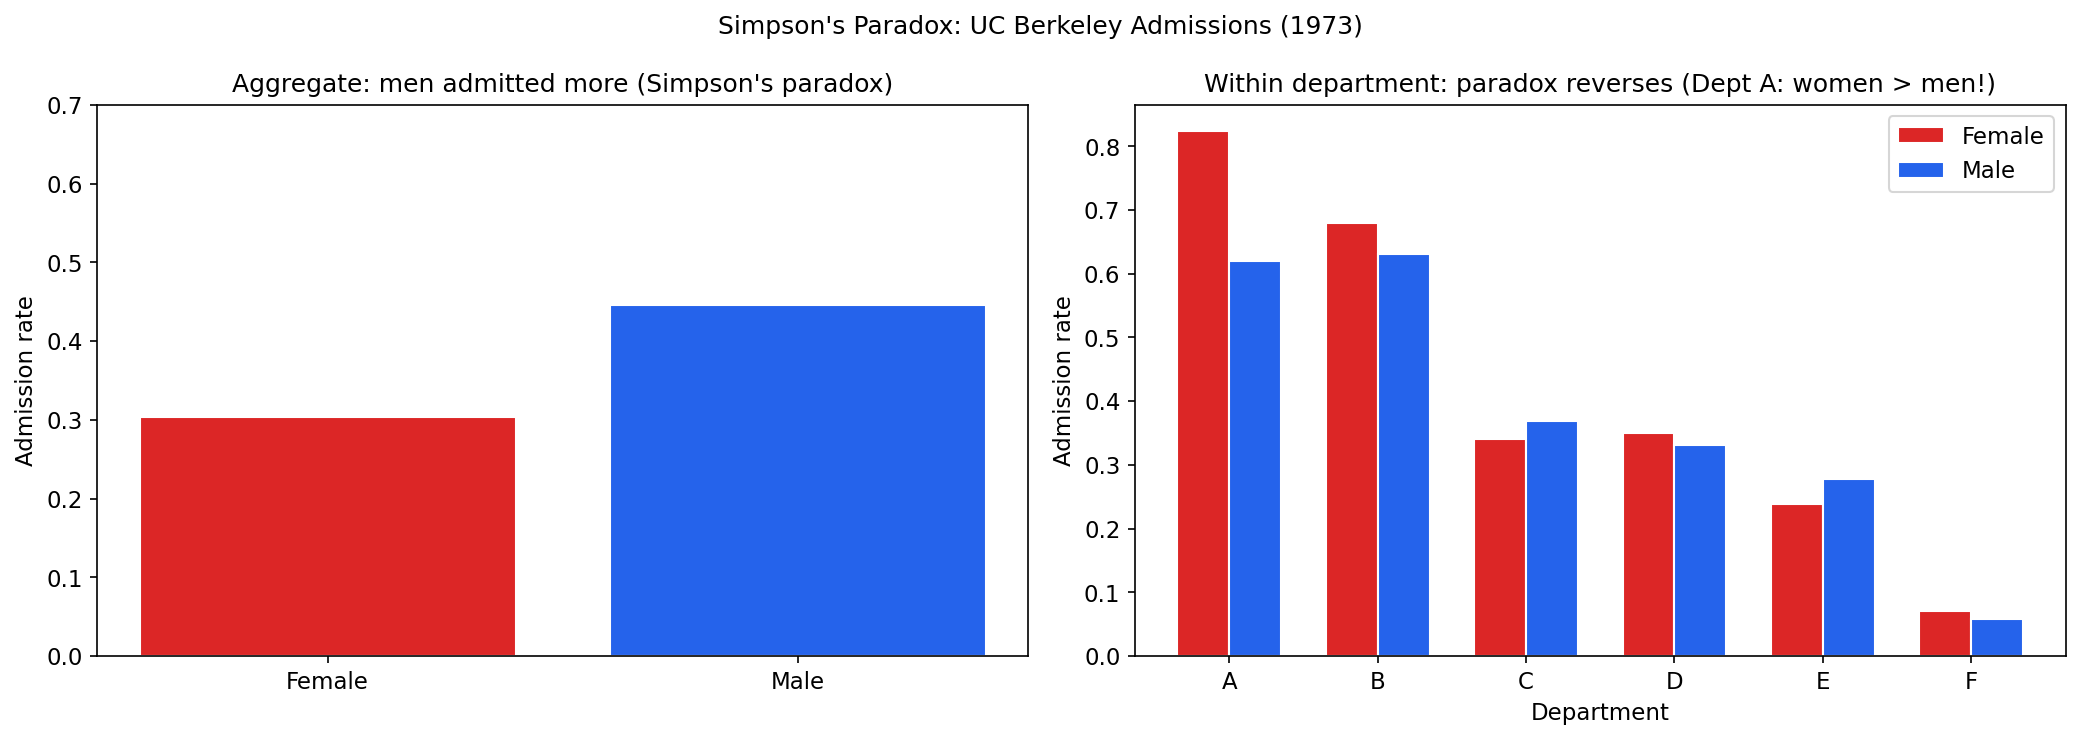

In [5]:
# Visualize the paradox
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: aggregate
agg_rates = [agg.loc["female", "rate"], agg.loc["male", "rate"]]
axes[0].bar(["Female", "Male"], agg_rates, color=[C_LIKELIHOOD, C_POSTERIOR], edgecolor="white")
axes[0].set_title("Aggregate: men admitted more (Simpson's paradox)")
axes[0].set_ylabel("Admission rate")
axes[0].set_ylim(0, 0.7)

# Right: by department
depts = sorted(berk["dept"].unique())
width = 0.35
x_pos = np.arange(len(depts))
f_rates = [berk[(berk["dept"]==d)&(berk["gender"]=="female")]["rate"].values[0] for d in depts]
m_rates = [berk[(berk["dept"]==d)&(berk["gender"]=="male")]["rate"].values[0] for d in depts]

axes[1].bar(x_pos - width/2, f_rates, width, color=C_LIKELIHOOD, edgecolor="white", label="Female")
axes[1].bar(x_pos + width/2, m_rates, width, color=C_POSTERIOR, edgecolor="white", label="Male")
axes[1].set_title("Within department: paradox reverses (Dept A: women > men!)")
axes[1].set_xlabel("Department"); axes[1].set_ylabel("Admission rate")
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(depts); axes[1].legend()

plt.suptitle("Simpson's Paradox: UC Berkeley Admissions (1973)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Binomial Regression: Total vs Direct Effect

**Total effect:** $\text{logit}(p_i) = \alpha_{G[i]}$ (no department)

**Direct effect:** $\text{logit}(p_i) = \alpha_{G[i], D[i]}$ (stratify by department)

In [6]:
# Total effect model on real Berkeley data
admitted = berk["admitted"].values
applied = berk["applied"].values
gender = berk["gender_idx"].values  # 0=female, 1=male
dept = berk["dept_idx"].values

def quap_total_binom(admitted, applied, gender):
    """Fit total effect: logit(p) = alpha[gender]."""
    def neg_lp(params):
        alpha = params[:2]
        p = expit(alpha[gender])
        ll = np.sum(stats.binom.logpmf(admitted, applied, p))
        lp = np.sum(stats.norm.logpdf(alpha, 0, 1.5))
        return -(ll + lp)
    res = optimize.minimize(neg_lp, [0.0, 0.0], method="Nelder-Mead")
    eps = 1e-5
    hess = np.zeros((2, 2))
    for i in range(2):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(res.x, gi, eps)
    cov = np.linalg.inv(hess)
    rng_q = np.random.default_rng(SEED)
    samp = rng_q.multivariate_normal(res.x, cov, size=N_SAMPLES)
    return {"mode": res.x, "samples": samp}

fit_total = quap_total_binom(admitted, applied, gender)

print("Total effect (log-odds scale):")
print(f"  alpha_female = {fit_total['mode'][0]:.3f} -> p = {expit(fit_total['mode'][0]):.3f}")
print(f"  alpha_male   = {fit_total['mode'][1]:.3f} -> p = {expit(fit_total['mode'][1]):.3f}")

# Contrast on probability scale
p_f = expit(fit_total["samples"][:, 0])
p_m = expit(fit_total["samples"][:, 1])
contrast = p_m - p_f
ci = np.percentile(contrast, [5.5, 94.5])
print(f"\nTotal effect (probability): male - female = {contrast.mean():.3f} [{ci[0]:.3f}, {ci[1]:.3f}]")

Total effect (log-odds scale):
  alpha_female = -0.830 -> p = 0.304
  alpha_male   = -0.220 -> p = 0.445

Total effect (probability): male - female = 0.141 [0.118, 0.165]


In [7]:
# Direct effect model: stratify by department
def quap_direct_binom(admitted, applied, gender, dept, n_depts=6):
    """Fit direct effect: logit(p) = alpha[gender, dept]."""
    n_params = 2 * n_depts
    def neg_lp(params):
        alpha = params.reshape(2, n_depts)
        p = expit(alpha[gender, dept])
        ll = np.sum(stats.binom.logpmf(admitted, applied, p))
        lp = np.sum(stats.norm.logpdf(params, 0, 1.5))
        return -(ll + lp)
    x0 = np.zeros(n_params)
    res = optimize.minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 50_000})
    eps = 1e-5
    hess = np.zeros((n_params, n_params))
    for i in range(n_params):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(res.x, gi, eps)
    try:
        cov = np.linalg.inv(hess)
    except np.linalg.LinAlgError:
        cov = np.eye(n_params) * 0.01
    rng = np.random.default_rng(SEED)
    samp = rng.multivariate_normal(res.x, cov, size=N_SAMPLES)
    return {"mode": res.x.reshape(2, n_depts), "samples": samp, "n_depts": n_depts}

n_depts = len(berk["dept"].unique())
fit_direct = quap_direct_binom(admitted, applied, gender, dept, n_depts=n_depts)

# Department-specific contrasts
print("Direct effect by department (probability scale, male - female):")
dept_names = sorted(berk["dept"].unique())
for d in range(n_depts):
    p_f_d = expit(fit_direct["samples"][:, d])
    p_m_d = expit(fit_direct["samples"][:, n_depts + d])
    delta = p_m_d - p_f_d
    ci = np.percentile(delta, [5.5, 94.5])
    print(f"  Dept {dept_names[d]}: {delta.mean():+.3f} [{ci[0]:+.3f}, {ci[1]:+.3f}]")

Direct effect by department (probability scale, male - female):
  Dept A: +0.355 [+0.278, +0.426]
  Dept B: -0.165 [-0.229, -0.064]
  Dept C: +0.093 [+0.039, +0.147]
  Dept D: -0.082 [-0.135, -0.027]
  Dept E: +0.083 [+0.015, +0.152]
  Dept F: -0.019 [-0.067, +0.029]


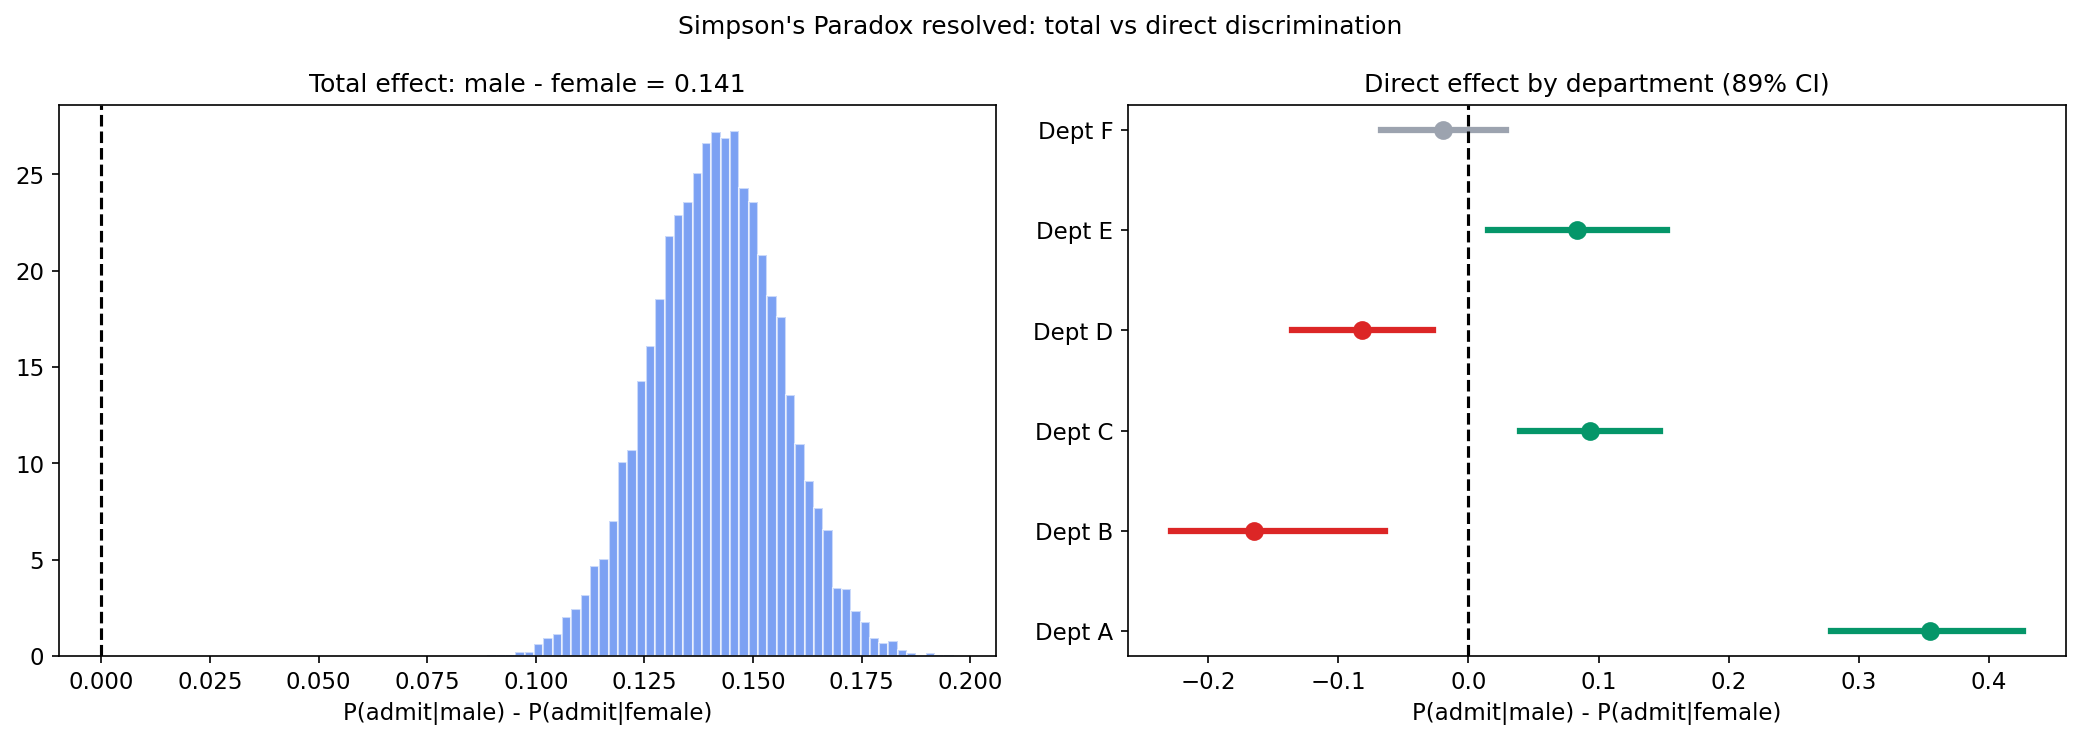

Red = significant male advantage. Green = significant female advantage. Gray = overlaps zero.


In [8]:
# Visualize: total vs direct contrasts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total contrast
axes[0].hist(contrast, bins=50, density=True, alpha=0.6, color=C_POSTERIOR, edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title(f"Total effect: male - female = {contrast.mean():.3f}")
axes[0].set_xlabel("P(admit|male) - P(admit|female)")

# Direct contrasts by department
dept_contrasts = []
for d in range(n_depts):
    p_f_d = expit(fit_direct["samples"][:, d])
    p_m_d = expit(fit_direct["samples"][:, n_depts + d])
    dept_contrasts.append(p_m_d - p_f_d)

dept_names = sorted(berk["dept"].unique())
for d, dc in enumerate(dept_contrasts):
    ci = np.percentile(dc, [5.5, 94.5])
    color = C_LIKELIHOOD if ci[1] < 0 else (C_DATA if ci[0] > 0 else C_PRIOR)
    axes[1].plot([ci[0], ci[1]], [d, d], color=color, linewidth=3)
    axes[1].plot(dc.mean(), d, "o", color=color, markersize=8)

axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_yticks(range(n_depts))
axes[1].set_yticklabels([f"Dept {d}" for d in dept_names])
axes[1].set_title("Direct effect by department (89% CI)")
axes[1].set_xlabel("P(admit|male) - P(admit|female)")

plt.suptitle("Simpson's Paradox resolved: total vs direct discrimination", fontsize=12)
plt.tight_layout()
plt.show()

print("Red = significant male advantage. Green = significant female advantage. Gray = overlaps zero.")

## 5. Post-Stratification

Transport estimates to a target population with different department sizes. Weight each department's effect by its proportion in the target population.

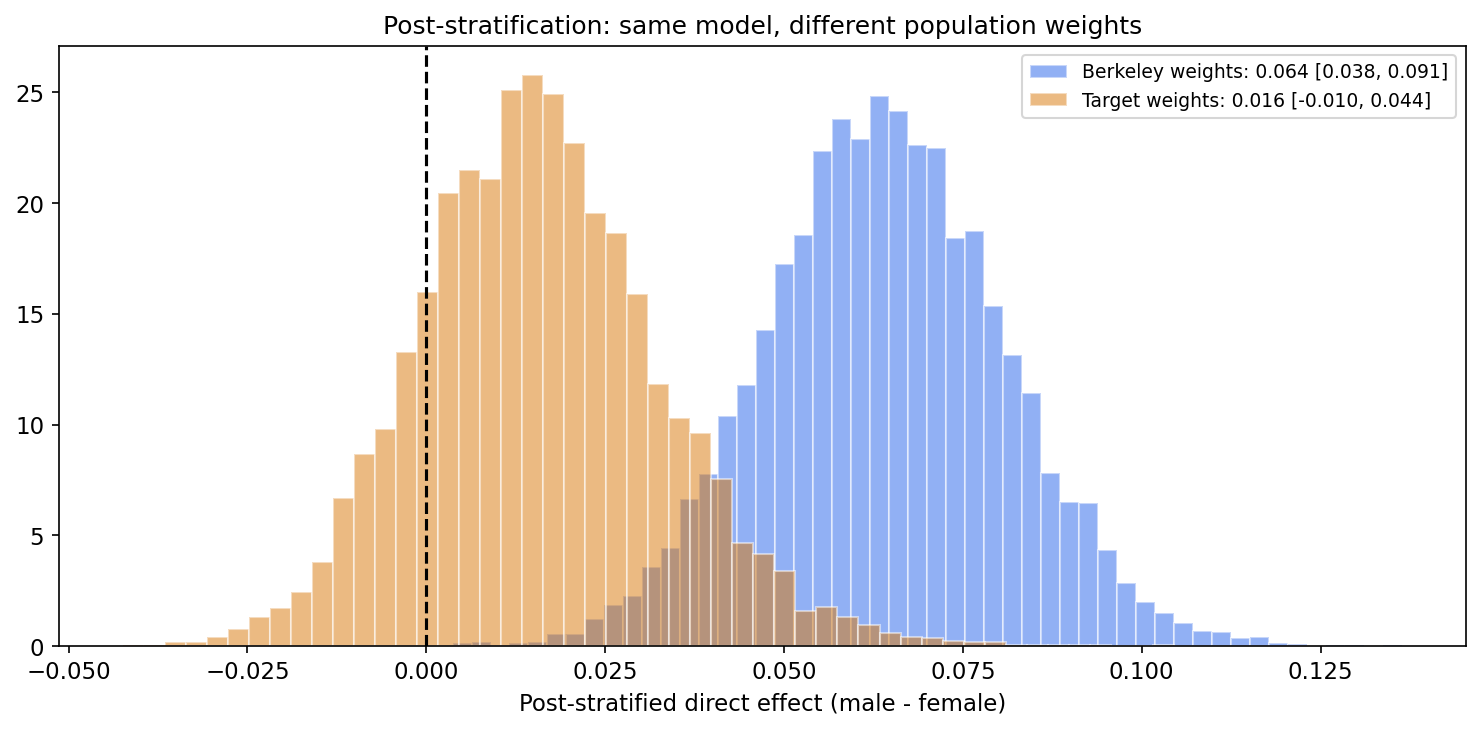

Different application distributions produce different average effects.
Post-stratification accounts for structural differences between populations.


In [9]:
# Post-stratification: predict for a different university
# Hypothetical target: engineering (dept A) is small, others are large
target_apps = np.array([50, 100, 100, 100, 100, 100])
target_weights = target_apps / target_apps.sum()

# Berkeley actual application distribution
berk_apps_total = berk.groupby("dept")["applied"].sum().sort_index().values
berk_weights = berk_apps_total / berk_apps_total.sum()

# Post-stratified direct effect
def post_stratified_effect(dept_contrasts, weights):
    stacked = np.column_stack(dept_contrasts)
    return stacked @ weights

effect_berk = post_stratified_effect(dept_contrasts, berk_weights)
effect_target = post_stratified_effect(dept_contrasts, target_weights)

fig, ax = plt.subplots(figsize=(10, 5))
ci_b = np.percentile(effect_berk, [5.5, 94.5])
ci_t = np.percentile(effect_target, [5.5, 94.5])

ax.hist(effect_berk, bins=50, density=True, alpha=0.5, color=C_POSTERIOR, edgecolor="white",
        label=f"Berkeley weights: {effect_berk.mean():.3f} [{ci_b[0]:.3f}, {ci_b[1]:.3f}]")
ax.hist(effect_target, bins=50, density=True, alpha=0.5, color=C_ACCENT, edgecolor="white",
        label=f"Target weights: {effect_target.mean():.3f} [{ci_t[0]:.3f}, {ci_t[1]:.3f}]")
ax.axvline(0, color="black", linestyle="--")
ax.set_xlabel("Post-stratified direct effect (male - female)")
ax.set_title("Post-stratification: same model, different population weights")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Different application distributions produce different average effects.")
print("Post-stratification accounts for structural differences between populations.")

---

# Part 2: Applied Exercises with Slovenian Data

In [10]:
re = pd.read_csv(DATA_DIR / "sr2026_real_estate.csv", parse_dates=["date"])
forensic = pd.read_csv(DATA_DIR / "sr2026_forensic_audio.csv")
crime = pd.read_csv(DATA_DIR / "sr2026_crime.csv")
mun = pd.read_csv(DATA_DIR / "sr2026_municipality_panel.csv")

YEAR_MIN = 2022

## Exercise 1: Binomial Regression — Property Transactions Above Threshold

**Estimand:** Does property type affect the probability of selling above 3,000 EUR/m2, controlling for municipality?

Same structure as Berkeley: type = gender, municipality = department, above-threshold = admission.

$$A_i \sim \text{Binomial}(N_i, p_i), \quad \text{logit}(p_i) = \alpha_{T[i], M[i]}$$

In [11]:
# Aggregate: count above threshold by property_type x municipality
re_recent = re[
    (re["year"] >= YEAR_MIN)
    & re["price_per_m2"].notna()
    & re["property_type"].isin(["apartment", "detached_house"])
    & re["municipality"].isin(re["municipality"].value_counts().head(5).index)
].copy()

THRESHOLD = 3_000
re_recent["above"] = (re_recent["price_per_m2"] > THRESHOLD).astype(int)

agg_re = (
    re_recent.groupby(["property_type", "municipality"])
    .agg(n_above=("above", "sum"), n_total=("above", "count"))
    .reset_index()
)

type_map = {"apartment": 0, "detached_house": 1}
mun_list = sorted(agg_re["municipality"].unique())
mun_map = {m: i for i, m in enumerate(mun_list)}
agg_re["tidx"] = agg_re["property_type"].map(type_map)
agg_re["midx"] = agg_re["municipality"].map(mun_map)
n_mun = len(mun_list)

print(f"Types: {list(type_map.keys())}")
print(f"Municipalities: {mun_list}")
print(f"Groups: {len(agg_re)}")

# Total effect: above ~ type (no municipality)
agg_type = re_recent.groupby("property_type").agg(
    n_above=("above", "sum"), n_total=("above", "count")
).reset_index()
for _, row in agg_type.iterrows():
    print(f"  {row['property_type']:20s}: {row['n_above']:,}/{row['n_total']:,} = {row['n_above']/row['n_total']:.3f}")

Types: ['apartment', 'detached_house']
Municipalities: ['CELJE', 'KOPER', 'KRANJ', 'LJUBLJANA', 'MARIBOR']
Groups: 10
  apartment           : 3,213/7,436 = 0.432
  detached_house      : 166/1,303 = 0.127


In [12]:
# Fit: total effect (type only) vs direct effect (type + municipality)
# Total
t_admitted = agg_type["n_above"].values
t_applied = agg_type["n_total"].values
t_gender = np.array([type_map[t] for t in agg_type["property_type"]])

fit_t_re = quap_total_binom(t_admitted, t_applied, t_gender)
p_apt = expit(fit_t_re["samples"][:, 0])
p_house = expit(fit_t_re["samples"][:, 1])
contrast_type = p_apt - p_house
ci_t = np.percentile(contrast_type, [5.5, 94.5])

print(f"Total effect (apartment - house): {contrast_type.mean():.3f} [{ci_t[0]:.3f}, {ci_t[1]:.3f}]")
print(f"  P(above 3K | apartment) = {p_apt.mean():.3f}")
print(f"  P(above 3K | house)     = {p_house.mean():.3f}")

# Direct effect (stratified by municipality)
d_admitted = agg_re["n_above"].values
d_applied = agg_re["n_total"].values
d_type = agg_re["tidx"].values
d_mun = agg_re["midx"].values

fit_d_re = quap_direct_binom(d_admitted, d_applied, d_type, d_mun, n_depts=n_mun)

print(f"\nDirect effect by municipality (apartment - house):")
for m_idx, m_name in enumerate(mun_list):
    p_apt_m = expit(fit_d_re["samples"][:, m_idx])
    p_house_m = expit(fit_d_re["samples"][:, n_mun + m_idx])
    delta = p_apt_m - p_house_m
    ci = np.percentile(delta, [5.5, 94.5])
    print(f"  {m_name:20s}: {delta.mean():+.3f} [{ci[0]:+.3f}, {ci[1]:+.3f}]")

Total effect (apartment - house): 0.304 [0.286, 0.321]
  P(above 3K | apartment) = 0.432
  P(above 3K | house)     = 0.128

Direct effect by municipality (apartment - house):
  CELJE               : -0.354 [-0.416, -0.289]
  KOPER               : +0.593 [+0.537, +0.645]
  KRANJ               : -0.345 [-0.406, -0.278]
  LJUBLJANA           : +0.406 [+0.367, +0.442]
  MARIBOR             : -0.110 [-0.142, -0.081]


## Exercise 2: Forensic Audio — Logistic Regression for Authenticity

**Estimand:** Does ENF SNR predict authenticity? Binary outcome (authentic/manipulated).

$$\text{is\_authentic}_i \sim \text{Bernoulli}(p_i), \quad \text{logit}(p_i) = \alpha + \beta \cdot \text{ENF\_SNR}_i$$

In [13]:
# Forensic logistic regression: ENF SNR -> authenticity
for_clean = forensic[forensic["enf_snr_50hz"].notna()].copy()
enf_s = (for_clean["enf_snr_50hz"] - for_clean["enf_snr_50hz"].mean()) / for_clean["enf_snr_50hz"].std()
y_auth = for_clean["is_authentic"].values

def quap_logistic(y, x):
    """Fit logistic regression: y ~ Bernoulli(logistic(alpha + beta*x))."""
    def neg_lp(params):
        alpha, beta = params
        p = expit(alpha + beta * x)
        p = np.clip(p, 1e-10, 1 - 1e-10)
        ll = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
        lp = stats.norm.logpdf(alpha, 0, 1.5) + stats.norm.logpdf(beta, 0, 1)
        return -(ll + lp)
    res = optimize.minimize(neg_lp, [0.0, 0.0], method="Nelder-Mead")
    eps = 1e-5
    hess = np.zeros((2, 2))
    for i in range(2):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(res.x, gi, eps)
    try:
        cov = np.linalg.inv(hess)
    except np.linalg.LinAlgError:
        cov = np.eye(2) * 0.1
    rng = np.random.default_rng(SEED)
    samp = rng.multivariate_normal(res.x, cov, size=N_SAMPLES)
    return {"mode": res.x, "samples": samp}

fit_for = quap_logistic(y_auth, enf_s.values)

print(f"Logistic regression: is_authentic ~ ENF_SNR")
print(f"  alpha (intercept) = {fit_for['mode'][0]:.3f} -> baseline P(auth) = {expit(fit_for['mode'][0]):.3f}")
print(f"  beta (ENF effect) = {fit_for['mode'][1]:.3f}")
print(f"  1 SD increase in ENF -> odds ratio = {np.exp(fit_for['mode'][1]):.2f}")

Logistic regression: is_authentic ~ ENF_SNR
  alpha (intercept) = -0.639 -> baseline P(auth) = 0.345
  beta (ENF effect) = -0.389
  1 SD increase in ENF -> odds ratio = 0.68


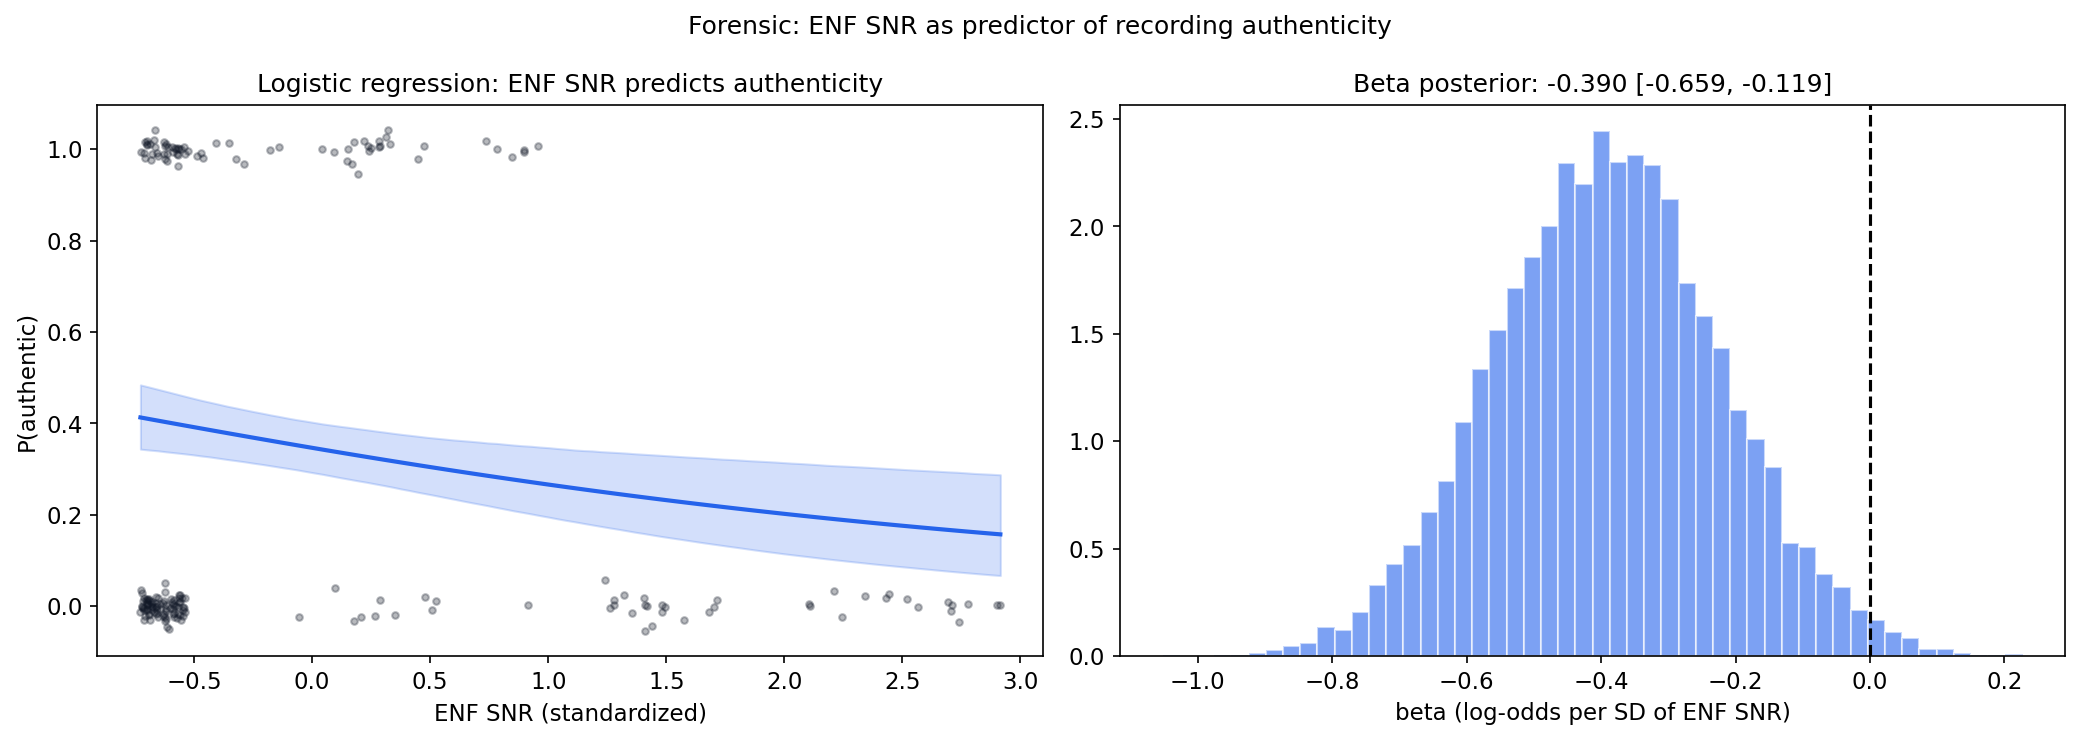

89% CI excludes zero: True
ENF SNR is a reliable predictor of authenticity on this dataset.


In [14]:
# Visualize logistic regression fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: data + fitted curve
enf_seq = np.linspace(enf_s.min(), enf_s.max(), 100)
alpha_samp = fit_for["samples"][:, 0]
beta_samp = fit_for["samples"][:, 1]

p_seq = expit(alpha_samp[:, None] + beta_samp[:, None] * enf_seq[None, :])
p_mean = p_seq.mean(axis=0)
p_lo = np.percentile(p_seq, 5.5, axis=0)
p_hi = np.percentile(p_seq, 94.5, axis=0)

axes[0].scatter(enf_s, y_auth + np.random.default_rng(1).normal(0, 0.02, len(y_auth)),
                alpha=0.3, s=10, color=C_POINT)
axes[0].plot(enf_seq, p_mean, color=C_POSTERIOR, linewidth=2)
axes[0].fill_between(enf_seq, p_lo, p_hi, alpha=0.2, color=C_POSTERIOR)
axes[0].set_xlabel("ENF SNR (standardized)")
axes[0].set_ylabel("P(authentic)")
axes[0].set_title("Logistic regression: ENF SNR predicts authenticity")

# Right: beta posterior
ci_b = np.percentile(beta_samp, [5.5, 94.5])
axes[1].hist(beta_samp, bins=50, density=True, alpha=0.6, color=C_POSTERIOR, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title(f"Beta posterior: {beta_samp.mean():.3f} [{ci_b[0]:.3f}, {ci_b[1]:.3f}]")
axes[1].set_xlabel("beta (log-odds per SD of ENF SNR)")

plt.suptitle("Forensic: ENF SNR as predictor of recording authenticity", fontsize=12)
plt.tight_layout()
plt.show()

excludes_zero = ci_b[0] > 0 or ci_b[1] < 0
print(f"89% CI excludes zero: {excludes_zero}")
if excludes_zero:
    print("ENF SNR is a reliable predictor of authenticity on this dataset.")
else:
    print("ENF SNR alone does not reliably predict authenticity.")

## Exercise 3: Post-Stratification for National Price Index

**Problem:** The ETN transaction dataset overrepresents Ljubljana. To compute a national proportion (above threshold), post-stratify by municipality housing stock.

Estimate municipality-specific proportions, then weight by population (proxy: total transactions over all years).

In [15]:
# Municipality-specific P(above 3K) for apartments, 2022+
apt_recent = re[
    (re["year"] >= YEAR_MIN)
    & (re["property_type"] == "apartment")
    & re["price_per_m2"].notna()
].copy()
apt_recent["above"] = (apt_recent["price_per_m2"] > THRESHOLD).astype(int)

# Top municipalities by transaction count
mun_counts = apt_recent["municipality"].value_counts()
top_munis = mun_counts[mun_counts >= 30].index.tolist()
apt_top = apt_recent[apt_recent["municipality"].isin(top_munis)]

mun_agg = apt_top.groupby("municipality").agg(
    n_above=("above", "sum"), n_total=("above", "count")
).reset_index()

# Beta-Binomial posterior for each municipality
mun_agg["post_mean"] = (mun_agg["n_above"] + 1) / (mun_agg["n_total"] + 2)

# Transaction-weighted national estimate (sample weighted)
sample_weight = mun_agg["n_total"] / mun_agg["n_total"].sum()
national_sample = (mun_agg["post_mean"] * sample_weight).sum()

# Post-stratified: weight by total housing stock proxy (all-years transaction count)
all_years_counts = re[re["property_type"] == "apartment"].groupby("municipality").size()
stock_weights = all_years_counts.reindex(mun_agg["municipality"]).fillna(0).values
stock_weights = stock_weights / stock_weights.sum()
national_poststrat = (mun_agg["post_mean"].values * stock_weights).sum()

print(f"Municipalities with n>=30: {len(mun_agg)}")
print(f"\nNational P(above {THRESHOLD:,} EUR/m2):")
print(f"  Sample-weighted:         {national_sample:.4f}")
print(f"  Post-stratified (stock): {national_poststrat:.4f}")
print(f"  Difference:              {national_poststrat - national_sample:+.4f}")
print("\nPost-stratification adjusts for Ljubljana overrepresentation in recent transactions.")

Municipalities with n>=30: 77

National P(above 3,000 EUR/m2):
  Sample-weighted:         0.2927
  Post-stratified (stock): 0.3001
  Difference:              +0.0074

Post-stratification adjusts for Ljubljana overrepresentation in recent transactions.


---

# Key Takeaways

1. **Events are counts. Use Binomial/Bernoulli, not Normal.** The logit link maps the linear predictor to the probability scale. Parameters live on log-odds, interpretation happens on probability.

2. **Simpson's paradox is causal, not statistical.** The aggregate gender gap in admissions reverses within departments because department mediates the effect. The DAG predicts this; aggregate correlation cannot.

3. **Total vs direct effect: different estimands, same DAG.** The Berkeley data show total discrimination (women admitted less) but minimal direct discrimination (within departments, rates are similar). The structural component dominates.

4. **Post-stratification transports estimates.** The same model applied to different populations (different department sizes, different municipality weights) gives different average effects. For the national price index, post-stratify by housing stock to correct for Ljubljana overrepresentation.

5. **Logistic regression for forensic classification.** ENF SNR predicts authenticity on a probability scale. The beta coefficient is a log-odds-ratio. Transform to probability for interpretation. The 89% CI tells you whether the predictor is reliable.

6. **Unmeasured confounders can mask discrimination.** Ability affects both department choice and admission. Without measuring it, the direct effect estimate may be biased. Cross-sectional data alone cannot fully identify discrimination.

**Next:** [[Lecture A10]] extends event models with confounding, sensitivity analysis, and unmeasured variables.